# E-Commerce Sales Analysis
## A Data Analyst Case Study

**Dataset:** UK-based Online Retail (2010-2011)

**Tool:** Python (Pandas, Matplotlib, Seaborn)

**By:** Hardeep Singh Dhaliwal


It is a UK-based online retail company that sells gifts and home decor products. The company mainly operates in the UK and also has some customers across Europe.

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv("data.csv", encoding="ISO-8859-1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
df.shape

(541909, 8)

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

<h1 style="text-align: center; color: black;">Analyze which countries are driving the majority of our orders for business decision-making.</h1>

In [7]:
ordercountrywise = df.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=False).head(10)
ordercountrywise

Country
United Kingdom    23494
Germany             603
France              461
EIRE                360
Belgium             119
Spain               105
Netherlands         101
Switzerland          74
Portugal             71
Australia            69
Name: InvoiceNo, dtype: int64

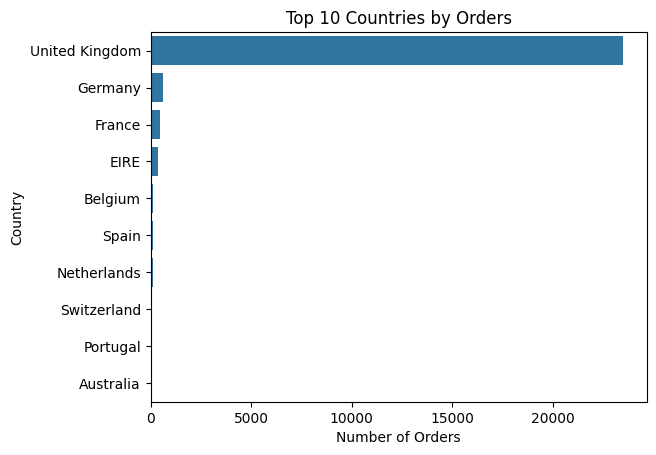

In [8]:
sns.barplot(y = ordercountrywise.index , x = ordercountrywise.values)
plt.title("Top 10 Countries by Orders")
plt.xlabel("Number of Orders")
plt.show()

Business Insight:

This business is almost entirely dependent on the UK market, while Germany and France contribute only a negligible share.

* The business has a strong presence in the UK market, so increasing investment there could drive further growth.
* However, this also creates a risk. if the UK market faces issues such as a recession or increased competition, the overall business could be significantly impacted
* There is an opportunity to expand in markets like Germany and France, where the current penetration is low but growth potential exists.

In [9]:
df = df.dropna(axis = 0 , subset = 'CustomerID')


There were 135,080 null values in CustomerID, which likely represent guest checkout orders where customers did not log in. These records were removed because they can affect repeat customer analysis, making it difficult to correctly identify returning customers and customer retention patterns.

In [10]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

<h1 style="text-align: center; color: black;">Analyze the monthly revenue performance.</h1>

In [11]:
df = df[df['Quantity'] > 0]
df['Revenue'] = df['Quantity'] * df['UnitPrice']
print("Total Revenue:-" , df['Revenue'].sum())

Total Revenue:- 8911407.904


In [12]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397924 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    397924 non-null  object 
 1   StockCode    397924 non-null  object 
 2   Description  397924 non-null  object 
 3   Quantity     397924 non-null  int64  
 4   InvoiceDate  397924 non-null  object 
 5   UnitPrice    397924 non-null  float64
 6   CustomerID   397924 non-null  float64
 7   Country      397924 non-null  object 
 8   Revenue      397924 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 30.4+ MB


In [14]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.month

In [15]:
df.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12


In [16]:
monthlyrev = df.groupby('Month').Revenue.sum()

In [17]:
monthlyrev

Month
1      569445.040
2      447137.350
3      595500.760
4      469200.361
5      678594.560
6      661213.690
7      600091.011
8      645343.900
9      952838.382
10    1039318.790
11    1161817.380
12    1090906.680
Name: Revenue, dtype: float64

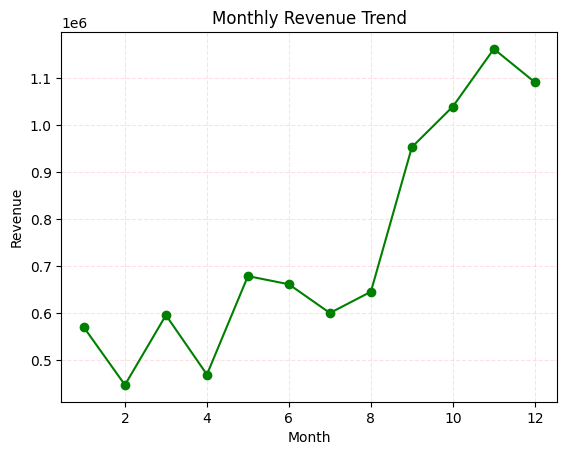

In [18]:
monthlyrev.plot(kind = 'line' , marker = 'o' , color='green')
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.grid(True , alpha = 0.5 , linestyle='--', color='pink')
plt.show()

What we observed:
The graph shows that revenue was low and mostly flat from months 1–4. From month 5, it started increasing steadily, reached its peak in month 11, and then dropped slightly in month 12.

Business Insight:

The business clearly follows a seasonal trend, especially because it is a UK gifting business.

* November is the peak month because of Christmas shopping, when people buy more gifts.
* January and February are naturally slower after the Christmas season.

Business decision: 
* Before the peak season, especially in October, the company should increase inventory, hire extra staff, and run more ads.
* There is also a small dip around March–April, so special offers or promotions could help increase sales during that time.

<h1 style="text-align: center; color: green;">Which are the top 10 products that generate the most revenue?</h1>

In [19]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12


In [20]:
top10products = df.groupby('Description')['Revenue'].sum().sort_values(ascending = False).head(10)

top10products

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: Revenue, dtype: float64

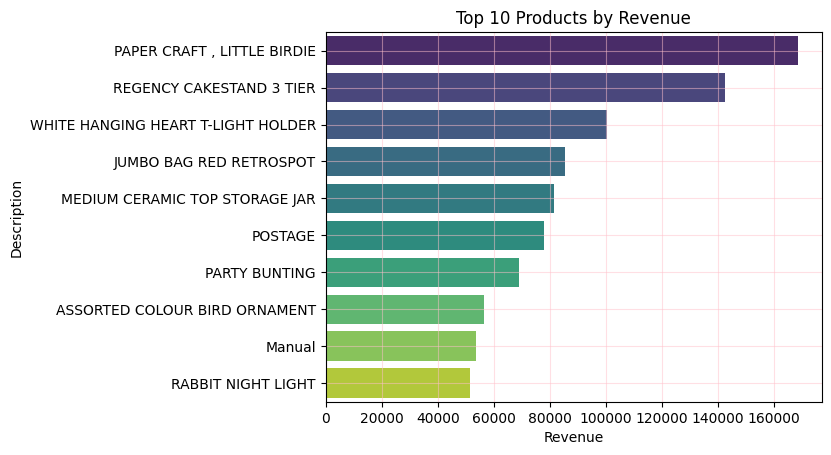

In [21]:
sns.barplot(x = top10products.values , 
            y = top10products.index, 
            palette="viridis",
            hue = top10products.index,
            legend = False)
plt.xlabel("Revenue")
plt.grid(alpha=0.5 , color = 'pink')
plt.title("Top 10 Products by Revenue")
plt.show()

<h1 style="text-align: center; color: green;">How many customers are repeat customers versus one-time customers?</h1>

In [22]:
df.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12


In [23]:
customers_orders = df.groupby('CustomerID')['InvoiceNo'].nunique()
repeat = (customers_orders > 1).sum()
onetime = (customers_orders == 1).sum()

print(f"Repeat Customers: {repeat}")
print(f"One-time Customer: {onetime}")

Repeat Customers: 2845
One-time Customer: 1494


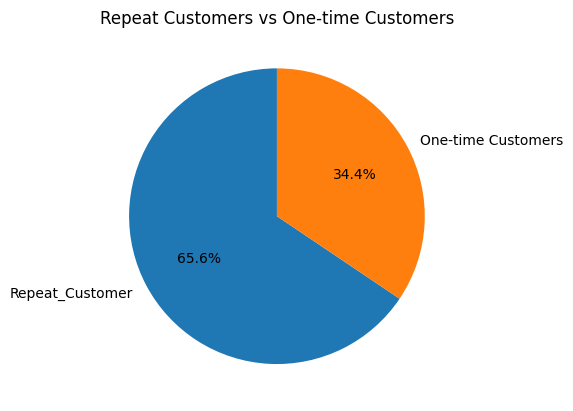

In [24]:
cust = [repeat , onetime]
labelss = ['Repeat_Customer' , 'One-time Customers']

plt.pie(cust , 
        labels = labelss , 
        autopct = '%1.1f%%',
        startangle = 90)
plt.title("Repeat Customers vs One-time Customers")
plt.show()

<h3 style = "color: green; font-size: 14px;">The analysis shows that only a few products are making most of the money, so the company should focus more on keeping these products in stock and promoting them more. 
It also shows that many customers come back and buy again, which means customers are happy with the products or service. 
But there are still many customers who buy only once, so the business should try to bring them back using discounts, loyalty programs, or special offers.</h3>

<h1 style = "color: purple; text-align: center; font-size: 45px;">RFM Analysis</h1>

* R - Recency
* F - Frequency
* M - Monetary

In [25]:
df.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12


In [26]:
#For Reference Date
from datetime import datetime

reference_date = df['InvoiceDate'].max() + pd.Timedelta(days = 1)
print(f"Reference Date: {reference_date}")

Reference Date: 2011-12-10 12:50:00


In [27]:
#RFM TABLE 
rfm = df.groupby('CustomerID').agg(
    Recency = ('InvoiceDate' , lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo' , 'nunique'),
    Monetary = ('Revenue' , 'sum')).reset_index()

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40
5,12352.0,36,8,2506.04
6,12353.0,204,1,89.00
7,12354.0,232,1,1079.40
8,12355.0,214,1,459.40
9,12356.0,23,3,2811.43


In [28]:
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=4, labels=[4,3,2,1])  # recency less days = high score (1 day = 4 score) 
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4])           #used rank because of duplicates values
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'),  q=4, labels=[1,2,3,4])

rfm['RFM_Score'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)     #qcut returns catagorial values thats why i used astype(int)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346.0,326,1,77183.60,1,1,4,6
1,12347.0,2,7,4310.00,4,4,4,12
2,12348.0,75,4,1797.24,2,3,4,9
3,12349.0,19,1,1757.55,3,1,4,8
4,12350.0,310,1,334.40,1,1,2,4


In [29]:
def segment(score):
    if score >= 10:
        return 'VIP'
    elif score >= 7:
        return 'Loyal'
    elif score >= 5:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(segment)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346.0,326,1,77183.60,1,1,4,6,At Risk
1,12347.0,2,7,4310.00,4,4,4,12,VIP
2,12348.0,75,4,1797.24,2,3,4,9,Loyal
3,12349.0,19,1,1757.55,3,1,4,8,Loyal
4,12350.0,310,1,334.40,1,1,2,4,Lost


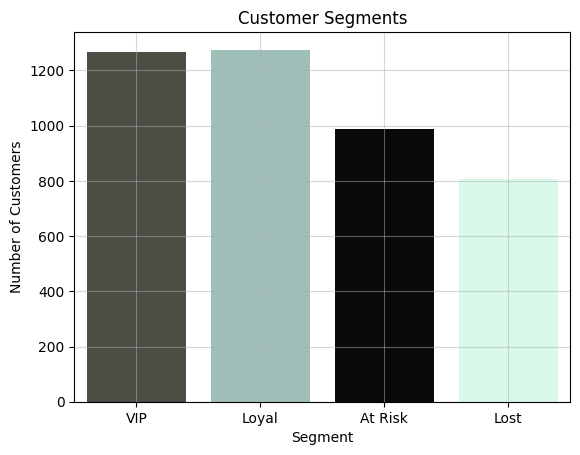

In [30]:
sns.countplot(data = rfm , 
              x = 'Segment' , 
              order = ['VIP' , 'Loyal' , 'At Risk' , 'Lost'],
             palette = ['#090909','#4B5043','#9BC4BC','#D3FFE9'],    #we can pick colors from https://coolors.co/  hehehe
             hue = 'Segment')
plt.title("Customer Segments")
plt.ylabel("Number of Customers")
plt.grid(alpha = 0.5)
plt.show()

# The analysis focused on:

* Understanding the revenue trend over time
* Identifying which products perform the best
* Measuring customer loyalty and repeat purchases
* Finding VIP customers and identifying customers who are likely to stop buying from the company

In [31]:
print(rfm['Segment'].value_counts())
print("\nAverage Spend per Segment:")
print(rfm.groupby('Segment')['Monetary'].mean().round(2))

Segment
Loyal      1275
VIP        1268
At Risk     989
Lost        807
Name: count, dtype: int64

Average Spend per Segment:
Segment
At Risk     521.43
Lost        222.57
Loyal      1076.12
VIP        5397.51
Name: Monetary, dtype: float64


In [32]:
total_customers = len(rfm)
vip_customers = 1268

vip_percentage = (vip_customers / total_customers) * 100
print(f"Total Customers: {total_customers}")
print(f"VIP: {round(vip_percentage,2)}%")

Total Customers: 4339
VIP: 29.22%


## Insights from RFM Analysis

### Customer Distribution
* Loyal customers: 1275 (largest customer group)
* VIP customers: 1268
* At Risk customers: 989
* Lost customers: 807

### Average Spend by Segment
* VIP customers spend an average of \$5397, which is nearly 5 times higher than Loyal customers.
* Loyal customers spend around \$1076 on average.
* At Risk customers spend about \$521, showing that they were once valuable customers but are now becoming inactive.
* Lost customers spend only \$222 on average, making them the lowest-value segment.

### Key Observation
VIP customers represent only 29% of the total customer base, but their average spending is 24 times higher than Lost customers. This means that retaining even a small number of VIP customers can have a major impact on overall revenue.

## Business Recommendations

### VIP Customers (1268)
* Offer exclusive memberships and early access to new products.
* Provide priority customer support because losing these customers would significantly affect revenue.
* Main goal: retain them.

### Loyal Customers (1275)
* Run campaigns such as "Spend $X more to become a VIP customer."
* Offer bundle deals and personalized product recommendations.
* Main goal: convert them into VIP customers.

### At Risk Customers (989)
* Launch "We miss you" email campaigns with discounts such as 15% off.
* These customers were previously active and can still be recovered.
* Main goal: re-engage them before they become Lost customers.

### Lost Customers (807)
* Send one final low-cost re-engagement campaign.
* If there is no response, avoid spending too many resources on them.
* Main goal: recover a small portion at minimal cost.

# Checking the order value distribution—do most customers place small orders or large ones?


In [33]:
print(df['Revenue'].describe())
print("\nKitni values hain 0-10 ke beech:")
print((df['Revenue'] < 10).sum())

count    397924.000000
mean         22.394749
std         309.055588
min           0.000000
25%           4.680000
50%          11.800000
75%          19.800000
max      168469.600000
Name: Revenue, dtype: float64

Kitni values hain 0-10 ke beech:
174727


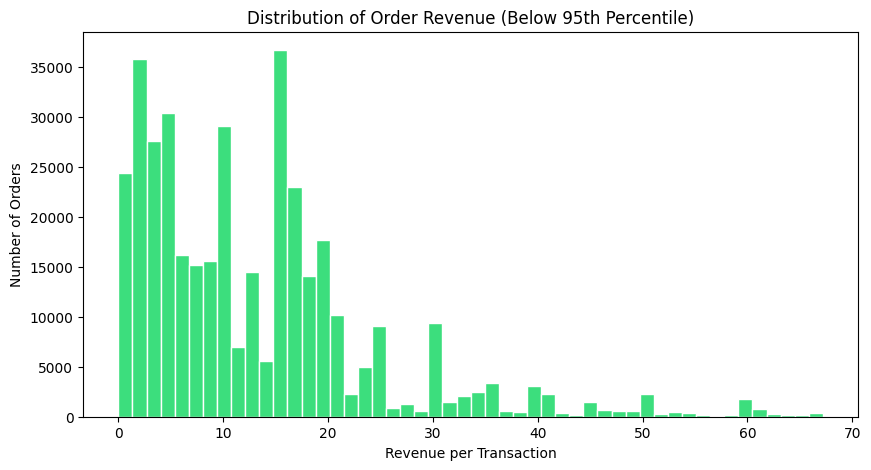

In [34]:
revenue_filtered = df[df['Revenue'] < df['Revenue'].quantile(0.95)]['Revenue']
# if you want top 5% values  -->    df[df['Revenue'] >= df['Revenue'].quantile(0.95)]['Revenue']
plt.figure(figsize=(10,5))
plt.hist(revenue_filtered, bins=50, color='#3cde7d' , edgecolor='white')
plt.title("Distribution of Order Revenue (Below 95th Percentile)")
plt.xlabel("Revenue per Transaction")
plt.ylabel("Number of Orders")
plt.show()

The graph shows three main things:

1. The graph is right-skewed, which means most customers place small-value orders, while only a few spend a large amount.
   
2. There are two peaks in the graph:
* One around \$2 - \\$4
* Another around \$15 - \\$16

This suggests there are two types of customers casual buyers who spend very little and regular buyers who spend a moderate amount.

3. Orders above \$30 are very rare, so high-value purchases do not happen often.

#Business Insights#:

* Since the average order value is only \\$11.80, the company could offer free shipping on orders above \\$20 to encourage customers to spend more.
* Customers spending \\$2–\\$4 could be targeted with bundle offers such as "Buy 3 items and get 10% off."
* Customers spending around \\$15–\\$16 could be added to a loyalty or rewards program to increase repeat purchases.
* Because \$30+ orders are uncommon, the company should promote premium products or suggest related items to increase cart value.

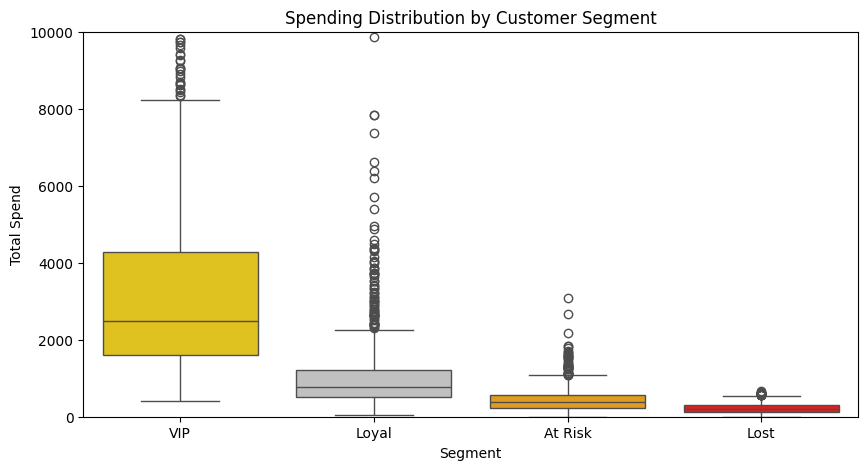

In [35]:
plt.figure(figsize=(10,5))
sns.boxplot(data=rfm, x='Segment', y='Monetary',
            order=['VIP','Loyal','At Risk','Lost'],
            palette=['orange','gold','silver','red'],
            hue = rfm['Segment'])
plt.title("Spending Distribution by Customer Segment")
plt.ylabel("Total Spend")
plt.ylim(0, 10000)
plt.show()

In [36]:
rfm['Monetary'].describe()

count      4339.000000
mean       2053.793018
std        8988.248381
min           0.000000
25%         307.245000
50%         674.450000
75%        1661.640000
max      280206.020000
Name: Monetary, dtype: float64

## Insights from the Graph

### VIP Customers
- Median spend is around **\$2,500**.
- The box is very large, meaning there is high variation among VIP customers. Some spend around **\$1,500**, while others spend over **\$4,000**.
- There are many high-value outliers, with some VIP customers spending between **\\$8,000 and \\$10,000**.

### Loyal Customers
- Median spend is around **\$800**.
- The smaller box shows that Loyal customers are more consistent spenders.
- Some outliers spend between **\\$4,000 and \\$7,000**, showing potential to become VIP customers.

### At-Risk Customers
- Median spend is around **$300**.
- The box is very small, meaning most customers in this segment spend less.
- These customers were previously active but are no longer highly engaged.

### Lost Customers
- Median spend is around **$200**.
- The box is almost flat, showing very low spending across the segment.
- Recovering these customers may be difficult.

---

## Business Decisions

### For VIP Customers
- High variation shows that VIP customers have different spending behaviors.
- Customers spending above **$8,000** can be categorized as **Platinum Members** since they are the highest-value customers.

### For Loyal Customers
- Some Loyal customers spending between **\\$4,000 and \\$7,000** are close to becoming VIPs.
- They can be targeted with messages such as:
  *You are only $X away from becoming a VIP member.*

### For At-Risk Customers
- Spending is low, but these customers can still be recovered.
- Personalized discounts should be offered quickly before they move into the Lost category.

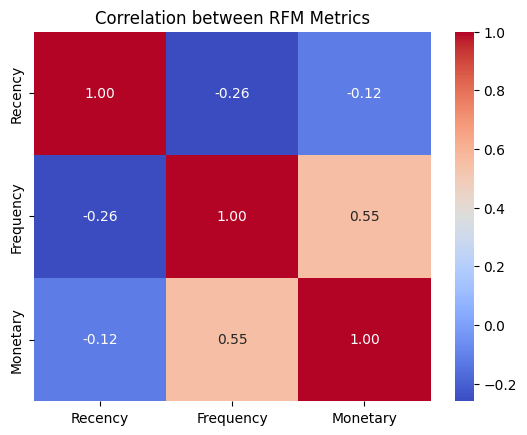

In [37]:
corr = rfm[['Recency', 'Frequency', 'Monetary']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm',  fmt='.2f')
plt.title("Correlation between RFM Metrics")
plt.show()

# Key Insights #

### (a) Frequency <---> Monetary = 0.55 (Strong Positive Correlation)
Customers who purchase more frequently tend to spend more money.

This means: Repeat customers are high-value customers

Insight: A large portion of revenue comes from loyal, repeat buyers.



### (b) Recency <---> Frequency = -0.26 (Weak Negative Correlation)
Customers who are more recent (lower recency value) tend to purchase slightly more frequently.
But the relationship is not strong.

Insight: Recently active customers are somewhat engaged, but not consistently loyal.

### (c) Recency <---> Monetary = -0.12 (Very Weak Negative Correlation)
There is almost no strong relationship between how recently a customer purchased and how much they spend.

Insight: Spending behavior is not strongly dependent on recency.

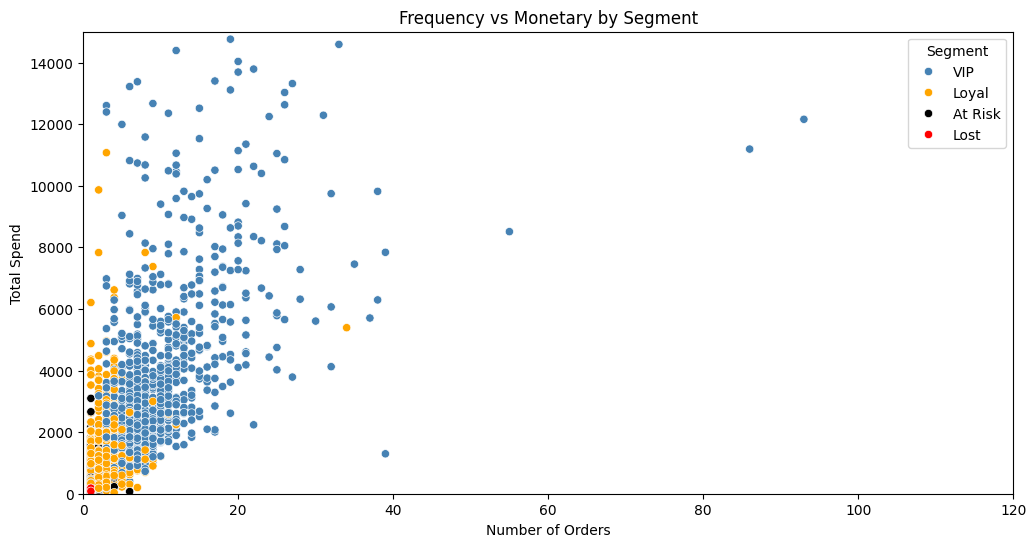

In [38]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=rfm, 
                x='Frequency', 
                y='Monetary',
                hue='Segment',
                palette=['steelblue','orange','black','red'],
                hue_order = ['VIP','Loyal','At Risk','Lost'])
plt.title("Frequency vs Monetary by Segment")
plt.xlabel("Number of Orders")
plt.ylabel("Total Spend")
plt.ylim(0, 15000)
plt.xlim(0,120)
plt.show()

We can divide the graph into 3 zones:

Zone 1 --> Left side (0–10 orders) :<br>This area has the highest number of dots, which means most customers place only a few orders.

Zone 2 --> Middle (10–40 orders):<br>
Most of the customers here are VIPs (blue dots), and they also tend to spend more.

Zone 3 --> Right side (40–100+ orders):<br>
Only VIP customers appear here these are the super loyal customers who keep coming back and ordering frequently.


# Pattern of Each Segment 

## VIP (Blue)

* Most of the dots appear in the upper-right area
* Order frequency ranges from 1 to 100 showing a wide variation
* Spending ranges between \\$500 and \\$14,000

Insight: There are two types of VIP customers some place large orders occasionally, while others order frequently and keep coming back.

## Loyal (Orange)

* Most of the dots are concentrated on the left side, around 1–15 orders
* Spending usually falls between \\$500 and \\$6,000

Insight: Some Loyal customers are already spending between \\$6,000 and \\$10,000, which means they are very close to becoming VIP they may just need a small push

## At Risk (Black)

* Usually have 1–5 orders with spending around \\$2,000–\\$3,500

Insight: These customers were actually good spenders before becoming inactive. If they return, they could quickly move back into the Loyal or even VIP segment, making them one of the most valuable recovery targets.


## Lost (Red)

* Mostly clustered near the bottom with very low activity and spending

Insight: These customers had very low value from the beginning

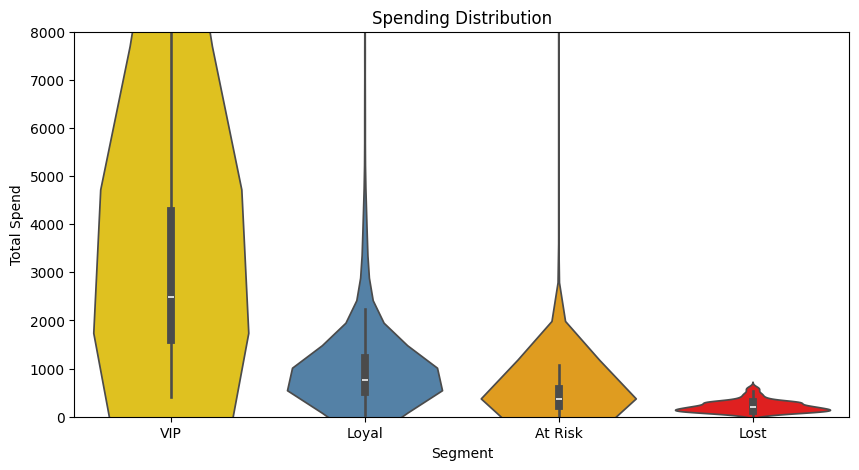

In [39]:
import warnings
warnings.filterwarnings('ignore')
plt.figure(figsize=(10,5))
sns.violinplot(data=rfm, 
               x='Segment', 
               y='Monetary',
               order=['VIP','Loyal','At Risk','Lost'],
               palette=['gold','steelblue','orange','red'])
plt.title("Spending Distribution")
plt.ylabel("Total Spend")
plt.ylim(0, 8000)
plt.show()


Key Insights:
1. VIP Customers

VIP's show a wide range of spending, from around \\$1000 up to \\$8000+.
This means they are not a uniform group. Some spend moderately, while a small portion are very high spenders and drive most of the value.

Basically, VIP's are a high-value but mixed behavior group.

2. Loyal Customers

Loyal customers are much more consistent. Most of them spend between \\$500 and \\$1500.

They form a stable base, and with a bit of effort, some of them could move into the VIP category.

3. At Risk Customers

This group used to spend well but is now declining. Their spending is mostly in the lower to mid range.

They are a strong opportunity group because with the right engagement, many could return as Loyal.

4. Lost Customers

Lost customers are mostly at the very bottom in terms of spending, with almost no meaningful activity.



Overall Picture

Most customers are concentrated in the lower to mid spending range, while a small VIP group contributes a large share of the value.

The key focus should be retaining VIP's, upgrading Loyal customers, and trying to win back At Risk customers.